In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение генератора случайных чисел
import random

In [ ]:
# Ячейка № 2

# задание функции,
# возвращающей значения
# потенциала Леннарда-Джонсона
def V(R):
    Np = len(R)
    z = np.zeros(Np)
    z = 4 * (1 / R**12 - 1 / R**6)

    return z


In [ ]:
# Ячейка № 3

# задание функции, возвращающей
# начальное состояние
# моделируемой системы
def Init(Lx, Ly, Nx, Ny, Vmax):
    #  входные переменные:
    # Lx - ширина МД ячейки
    # Ly - высота МД ячейки
    # Nx - ширина начальной ячейки
    # Ny - высота начальной ячейки
    # Vmax - максимальное значение скорости

    # вычисление числа вершин
    # используемых ячеек
    Pos_row = Ly / (Ny + 1)
    Pos_col = Lx / (Nx + 1)

    # вычисление числа частиц системы
    N = Nx * Ny

    # инициализация массивов, используемых
    # для хранения начальных значений
    # координат (x, y) и скоростей (Vx, Vy)
    # моделируемой системы
    x = np.zeros(N)
    y = np.zeros(N)
    Vx = np.zeros(N)
    Vy = np.zeros(N)

    # инициализация генератора случайных чисел
    random.seed()

    # задание начального состояния
    # моделируемой системы
    i = 0
    for Rows in range(Ny):
        for Cols in range(Nx):
            # задание начальных координат частиц
            x[i] = Pos_col * (Cols + 1) / 2
            y[i] = Pos_row * (Rows + 1)
            # задание начальных скоростей частиц
            Vx[i] = Vmax * (2 * random.uniform(0, 1) - 1)
            Vy[i] = Vmax * (2 * random.uniform(0, 1) - 1)
            i = i + 1

    # вычисление проекций скорости
    # центра масс моделируемой системы
    Vx_full = np.mean(Vx)
    Vy_full = np.mean(Vy)
    # вычисление отклонений
    # проекций скоростей
    # частиц от соответствующих
    # проекций скорости центра
    # масс моделируемой системы
    Vx = Vx - Vx_full
    Vy = Vy - Vy_full

    # размешение начальных значений
    # координат и скоростей частиц
    # моделируемой системы относительно
    # относительно ее центра масс
    # в массиве z
    z = np.vstack([x, y, Vx, Vy])

    # транспонирование матрицы z
    z = z.transpose()

    return z

In [4]:
# Ячейка № 4

# задание функции, возвращающей
# значение проекции на ось оХ
# силы, действующей на частицу
def Fx(x, y):
    z = (
        -(2 ** (7 / 3))
        * (np.pi**2)
        / 3
        * x
        * (-2 / (x**2 + y**2) ** 7 + 1 / (x**2 + y**2) ** 4)
    )
    return z

In [5]:
# Ячейка № 5

# задание функции, возвращающей
# значение проекции на ось оХ
# силы, действующей на частицу
def Fy(x, y):
    z = (
        -(2 ** (7 / 3))
        * (np.pi**2)
        / 3
        * y
        * (-2 / (x**2 + y**2) ** 7 + 1 / (x**2 + y**2) ** 4)
    )
    return z

In [6]:
# Ячейка № 6

# задание функции, возвращающей значения
# координат, составляющих скорости и
# ускорений вдоль соответствующих
# координатных осей
def Acc(R_V, Lx, Ly, N):
    # входные переменные:
    # R_V - матрица, возвращенная функцией Init
    # Lx - ширина МД ячейки
    # Ly - высота МД ячейки
    # N - число частиц моделируемой системы

    # инициализация массивов Ax, Ay,
    # используемых для хранения
    # значений проекций ускорений
    # частиц моделируемой системы
    Ax = np.zeros(N)
    Ay = np.zeros(N)

    # инициализация массива Pe,
    # используемого для хранения
    # потенциальной энергии взаимодействия
    # частиц моделируемой системы
    Pe = np.zeros(N)

    # вычисление значений проекций
    # ускорений частиц моделируемой системы
    # на оси координат и
    # потенциальной энергии взаимодействия
    # частиц моделируемой системы
    Ep = 0
    for i in range(N - 1):
        for j in range(i + 1, N):
            Dx = R_V[i, 0] - R_V[j, 0]
            Dy = R_V[i, 1] - R_V[j, 1]
            # проверка граничных
            # условий по оси ОX
            if abs(Dx) > Lx / 2:
                Dx = Dx - np.sign(Dx) * Lx
            # проверка граничных условий
            # по оси OY
            if abs(Dy) > Ly / 2:
                Dy = Dy - np.sign(Dy) * Ly

            # вычисление проекции ускорения на ось оХ
            Ax[i] = Ax[i] + Fx(Dx, Dy)
            Ax[j] = Ax[j] - Fx(Dx, Dy)  # третий закон Ньютона

            # вычисление проекции ускорения на ось оY
            Ay[i] = Ay[i] + Fy(Dx, Dy)
            Ay[j] = Ay[j] - Fy(Dx, Dy)  # третий закон Ньютона

            # вычисление расстояния между
            # i-ой и j-ой частицами
            r = np.sqrt(Dx**2 + Dy**2)

            # вычисление потенциальной энергии
            # взаимодействия между i-ой и j-ой частицами
            Ep = Ep + 4 * (1 / r**12 - 1 / r**6)

        # размещение значения потециальной энергии
        # в последнем элементе массива Pe
        Pe[N - 1] = Ep

    # размещение значений проекций
    # ускорений частиц моделируемой системы
    # на оси координат и
    # потенциальной энергии взаимодействия
    # в массиве z
    z = np.vstack([Ax, Ay, Pe])

    # транспонирование массива z
    z = z.transpose()

    return z


In [7]:
# Ячейка № 7

# задание функции, возвращающей значения
# мгновенных ускорений
# частиц моделируемой системы и
# мгновенные значения
# ее потенциальной энергии
def Verlet(R_V, Lx, Ly, N, dt):
    # входные переменные:
    # R_V - матрица, возвращенная функцией Init
    # Lx  - ширина МД ячейки
    # Ly - высота МД ячейки
    # N - число частиц системы
    # dt - шаг интегрирования

    # инициализация массивов x, y,
    # используемых для хранения
    # новых координат моделируемой системы
    x = np.zeros(N)
    y = np.zeros(N)
    for i in range(N - 1):
        # вычисление новых значений
        # координат данной частицы
        x[i] = R_V[i, 0] + R_V[i, 2] * dt + R_V[i, 4] * dt**2 / 2
        y[i] = R_V[i, 1] + R_V[i, 3] * dt + R_V[i, 5] * dt**2 / 2

        # перемещение при необходимости частицы
        # в центральную ячейку
        if x[i] < 0:
            x[i] = x[i] + Lx
        if x[i] > Lx:
            x[i] = x[i] - Lx
        if y[i] < 0:
            y[i] = y[i] + Ly
        if y[i] > Ly:
            y[i] = y[i] - Ly

    # инициализация массивов Vx, Vy,
    # используемых для хранения
    # "новых" значений проекций скоростей
    # моделируемой системы
    Vx = np.zeros(N)
    Vy = np.zeros(N)

    # изменение скорости с использованием
    # значения ускорения, вычисленного
    # на предыдущем шаге алгоритма
    Vx[:] = R_V[:, 2] + 0.5 * R_V[:, 4] * dt
    Vy[:] = R_V[:, 3] + 0.5 * R_V[:, 5] * dt

    # размещение "новых" значений координат и
    # проекций скоростей частиц моделируемой системы
    # в массиве R_Vnew
    R_Vnew = np.vstack([x, y, Vx, Vy])

    # транспонирование массива R_Vnew
    R_Vnew = R_Vnew.transpose()

    # вычисление "новых" значений ускорений
    Accnew = Acc(R_Vnew, Lx, Ly, N)

    # вычисление "новых" значений скорости
    # с использованием "новых" значений ускорения
    Vx[:] = Vx[:] + 0.5 * Accnew[:, 0] * dt
    Vy[:] = Vy[:] + 0.5 * Accnew[:, 1] * dt

    # размещение в массиве z
    # новых значений координат и
    # проекций скоростей
    z = np.vstack([x, y, Vx, Vy])

    # транспонирование массива z
    z = z.transpose()

    # добавление в массив z
    # массива Accnew
    z = np.hstack([z, Accnew])

    return z


In [8]:
# Ячейка № 8
# задание функции, возвращающей
# составной массив,
# содержащий значения координат,
# проекций скоростей и ускорений
# на соответствующие координатные оси
#  в узлах временной сетки


def Mol_din2(Lx, Ly, N, Ni, dt, A, Tf, Nm):
    # входные переменные
    # Lx - ширина МД ячейки
    # Ly  - высота МД ячейки
    # N - число частиц системы
    # Ni - число МД шагов
    # dt - шаг интегрирования уравнений движения
    # A - массив, возвращенный функцией Init

    # вычисление значений
    # ускорений частиц в
    # в момент времени t = 0
    Acc_old = Acc(A, Lx, Ly, N)

    # инициализация массива A2,
    # используемого для хранения
    # мгновенных значений координат (x,y),
    # скоростей (Vx,Vy) и ускорений (Ax,Ay)
    # каждой частицы моделируемой системы,
    # а также полной потенциальной энергии E0
    # формат массива:
    # [x, y, Vx, Vy, Ax, Ay, Ep]
    # размерность массива N x 7
    # структура вектора Ep:
    # Ep[i] = 0, i = 0,N-2; Ep[N-1] = E0
    A2 = np.hstack([A, Acc_old])

    # инициализация массива,
    # используемого  для хранения
    # мгновенных значений координат (x,y),
    # скоростей (Vx,Vy) и ускорений (Ax,Ay)
    # каждой частицы моделируемой системы,
    # а также полной потенциальной энергии Ep[0]
    # на каждом временном MD-шаге
    A_full = A2
    k = 0

    # вычисление мгновенных значений координат (x,y),
    # скоростей (Vx,Vy) и ускорений (Ax,Ay)
    # каждой частицы моделируемой системы,
    # а также полной потенциальной энергии Ep[i]
    # на каждом временном MD-шаге,
    # и размещение их в массиве A_full
    n = 0

    tmp_Vx = np.zeros(N)
    tmp_Vy = np.zeros(N)
    while k < Ni:
        # вычисление на k-ом временном шаге
        # мгновенных значений координат (x,y),
        # скоростей (Vx,Vy) и ускорений (Ax,Ay)
        # каждой частицы моделируемой системы,
        # а также полной потенциальной энергии Ep[i]
        # на каждом временном MD-шаге
        A2 = Verlet(A2, Lx, Ly, N, dt)
        if n < Nm - 1:
            n = n + 1

        else:
            # вычисление кинетической энергии
            E = np.zeros(N)

            # перемещение значений
            # проекций скорости на
            # оси координат каждой
            # частицы моделируемой системы
            # в массивы tmp_Vx, tmp_Vy
            tmp_Vx = A2[:, 2]
            tmp_Vy = A2[:, 3]

            # вычисление кинетических энергий
            # моделируемой системы
            E = E + 0.5 * (tmp_Vx**2 + tmp_Vy**2)

            n = 0
            # вычисление средней
            # кинетической энергии
            # моделируемой системы
            # в соответствие с (10.31)
            Ek_mean = np.mean(E)

            # вычисление значения
            # нормировочного коэффициента
            # beta в соответстиве с (10.32)
            Coeff = Tf / Ek_mean

            # пеернормировка скоростей
            # частиц моделируемой системы
            # в соответствие c (10.33)
            A2[:, 2] = A2[:, 2] * np.sqrt(Coeff)
            A2[:, 3] = A2[:, 3] * np.sqrt(Coeff)

        # дополнение массива A_full
        # массивом A2
        A_full = np.vstack([A_full, A2])

        k = k + 1

    return A_full

In [9]:
# Ячейка № 9

# вычисление мгновенных значений
# координат и скоростей частиц
# на каждом временном МД-шаге

# задание температуры
# моделируемой системы
Tf = 100

# число МД-шагов,
# используемых для
# вычисления среднего значения Ek
# в соответствие с (10.31),
#  коэффициента beta в соответствие с (10.32)
# и нормировкой значений скорости
# в соответствие с (10.33)
Nm = 200

# задание числа частиц N
Nx = 5
Ny = 5
N = Nx * Ny

# задание размера МД-ячейки
Lx = 8
Ly = 8

# инициализация начальной конфигурации
# частиц в МД-ячейке

# задание максимального
# значения начальной скорости
Vmax = 0.2
# вычисление нкоордиант и скоростей
# в момент времени t = 0
A = Init(Lx, Ly, Nx, Ny, Vmax)

# задание значения
# числа МД-шагов
Ni = 2 * 10**4

# задание значения
# МД-шага по времени
dt = 1 * 10**-4

# вызов функции, возвращающей
# мгновенные значения координат
# и скоростей частиц, вычисленных в
# соответствие с МД-методом, в виде
# трехмерного массива размерностью
# N x 7 x (Ni+1)
md = Mol_din2(Lx, Ly, N, Ni, dt, A, Tf, Nm)

# вычисление количества массивов A2,
# размещенных в массиве A_full
N_arr = Ni + 1

# инициализация массива z,
# имеющего размерность N x 7 х N_arr
z = np.zeros([N, 7, N_arr])

# перемещение массивов A2
# из массива  A_full, в массив z
for i in range(N_arr):
    z[:, :, i] = md[i * N : (i + 1) * N, :]

In [ ]:
# Ячейка № 10

# вычисление зависимостей:
# 1) суммарной кинетической энергии частиц,
# отнесенной к числу частиц;
# 2) суммарной потенциальной энергии
# взаимодействия частиц,
# отнесенной к числу частиц;
# 3) полной суммарной энергии частиц,
# отнесенной к числу частиц,
# 4) давления
# от времени

# задание числа массивов
# размерностью N x 7, размещенных
# в массиве md размерностью N x 7 X i
N_arr = Ni + 1

# инициализация массивов, используемых
# для вычисления мгновенных значений
# зависимостей суммарных
# кинетической (Ek[i]), потенциальной (Ep[i]),
# полной (Ek[i] + Ep[i]) энергий
#  частиц системы от времени
# (t[i] = i * dt)

tmp_Vx = np.zeros(N)
tmp_Vy = np.zeros(N)
Ek = np.zeros(N_arr)
Ep = np.zeros(N_arr)

# вычисление мгновенных значений
# зависимостей Ek[i],Ep[i]

for i in range(N_arr):
    Sum = 0
    tmp_Vx = z[:, 2, i]
    tmp_Vy = z[:, 3, 1]
    for j in range(N):
        Sum = Sum + 0.5 * (tmp_Vx[j] ** 2 + tmp_Vy[j] ** 2)
    Ek[i] = Sum
    Ep[i] = z[N - 1, 6, i]

# вычисление давления
# моделируемой системы
# в соответствие с (10.30)

P = np.zeros(N_arr)

tmp_x = np.zeros(N)
tmp_y = np.zeros(N)
tmp_ax = np.zeros(N)
tmp_ay = np.zeros(N)

# вычисление "объема"
# моделируемой системы
Vol = Lx * Ly
# вычисление произведения
# "объем" на число частиц системы
V_N = Vol * N
for i in range(N_arr):
    # размещение абсцисс
    # частиц на i-ом МД-шаге
    # в массиве tmp_x
    tmp_x = z[:, 0, i]

    # размещение ординат
    # частиц на i-ом МД-шаге
    # в массиве tmp_y
    tmp_y = z[:, 1, i]

    # размещение значений
    # составляющей ускорения
    # вдоль оси OX
    # на i-ом МД-шаге
    # в массиве tmp_ax
    tmp_ax = z[:, 4, i]

    # размещение значений
    # составляющей ускорения
    # вдоль оси OY
    # на i-ом МД-шаге
    # в массиве tmp_ay
    tmp_ay = z[:, 5, i]

    # вычисление температуры
    # моделируемой системы
    # на i-ом МД-шаге
    P[i] = 0.5 * (np.dot(tmp_x, tmp_ax) + np.dot(tmp_y, tmp_ay)) / V_N + Ek[i] / Vol

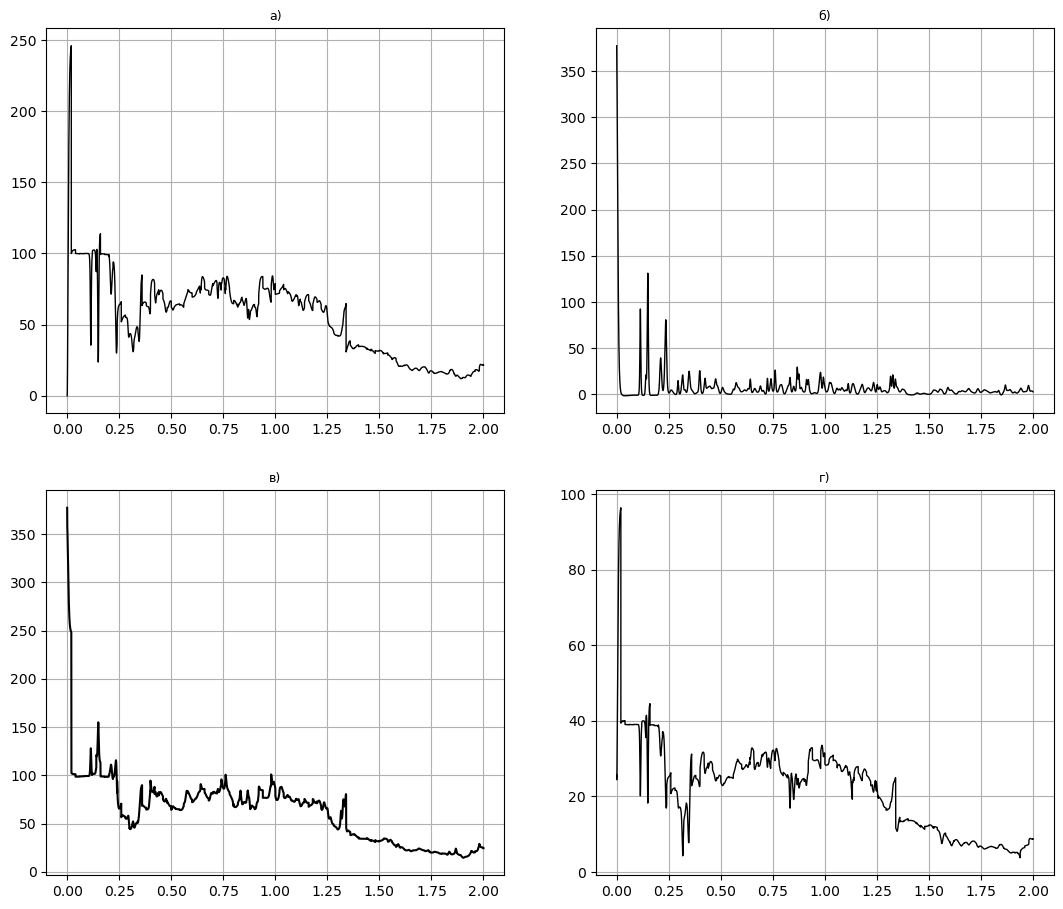

In [11]:
# Ячейка № 11

# визуализация зависимостей
# N_left[i]/N, Ek[i]/N, Ep[i]/N,
# (Ek[i] + Ep[i]) / N


fig = plt.figure(figsize=(13, 11))
# визуализация вектора напряженности
# электрического поля в точке y = 0
ax = plt.subplot(2, 2, 1)

i = np.arange(0, N_arr, 1, dtype=int)

ax = plt.subplot(2, 2, 1)
ax.plot(i * dt, Ek[i] / N, "-k", lw=1)
ax.grid(True)
ax.set_title("a)", fontsize=9)

ax = plt.subplot(2, 2, 2)
ax.plot(i * dt, Ep[i] / N, "-k", lw=1)
ax.grid(True)
ax.set_title("б)", fontsize=9)

ax = plt.subplot(2, 2, 3)
ax.plot(i * dt, (Ek[i] + Ep[i]) / N, color="black")
ax.grid(True)
ax.set_title("в)", fontsize=9)

ax = plt.subplot(2, 2, 4)
ax.plot(i * dt, P[i], "-k", lw=1)
ax.grid(True)
ax.set_title("г)", fontsize=9)

plt.show()

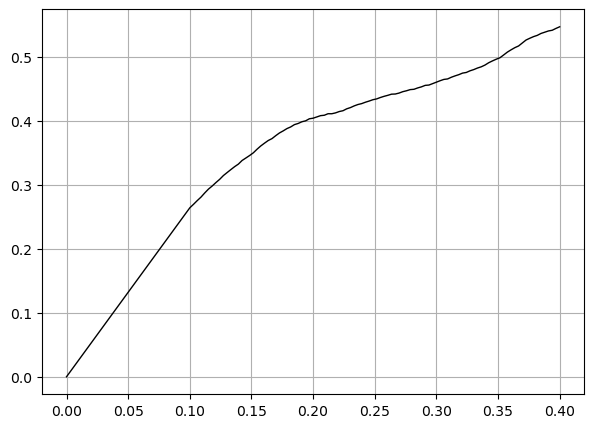

In [12]:
# Ячейка № 12

# вычисление зависимости
# среднего по времени
# и всем частицам
# квадрата смещения от времени

# задание функции, возвращающей
# значения зависимости
# среднего по времени
# и всем частицам
# квадрата смещения от времени
# заданных значений t1, t2
# в соответствие с (9.36)


def R2(z, N, Lx, Ly, N_start, dK):
    i = 0
    Dx = 0
    Dy = 0
    j = 0
    R = 0

    while N_start + (i + 1) * dK < z.shape[2] - 1:
        while N_start + (i + 1) * dK + j < z.shape[2] - 1 - dK:
            for m in range(N):
                Dx = z[m, 0, i + N_start + j] - z[m, 0, N_start + (i + 1) * dK + j]

                Dy = z[m, 1, i + N_start + j] - z[m, 1, N_start + (i + 1) * dK + j]

                R = R + Dx**2 + Dy**2

                j = j + 1

        i = i + 1

    R = R / (N * j)
    return R


# задание момента времени,
# начиная с которого
# состояние системы
# считается равновесным
T_start = 0.5

# вычисление номера элемента
# массива z, соответствующего
# T_start
N_start = int(T_start / dt)

# создание массива,
# содержащего значения
# длин отрезка [t1,t2]
Delta_t = np.linspace(0.1, 0.4, 100)


# задание функций f(x), f2(х)
# обеспечивающие вычисление
# целочисленных значений
# элементов массива
def f(x):
    return int(x)


f2 = np.vectorize(f)

# вычисляем значения номеров
# МД-шаг, соответствующих
# элементам массива z
Dk = f2(Delta_t / dt)

# инициализация массива,
# используемого для
# для хранения
# значений зависимости
# среднего по времени
# и всем частицам
# квадрата смещения от времени
# для заданных значений t1, t2,
# вычисленных в соответствие с (9.36)
R = np.zeros(len(Delta_t) + 1)


# вычисление значений зависимости
# среднего по времени
# и всем частицам
# квадрата смещения от времени
# для заданных значений t1, t2,
# вычисленных в соответствие с (9.36)
R = np.zeros(len(Delta_t) + 1)
for i in range(len(Delta_t)):
    R[i + 1] = R2(z, N, Lx, Ly, N_start, Dk[i])

# визуализация зависимости
# среднего по времени
# и всем частицам
# квадрата смещения от времени
# для заданных значений t1, t2
# в соответствие с (9.36)

Delta_t = np.hstack((0, Delta_t))
fig = plt.figure(figsize=(7, 5))
plt.plot(Delta_t, R, "-k", lw=1)
plt.grid(True)

plt.show()

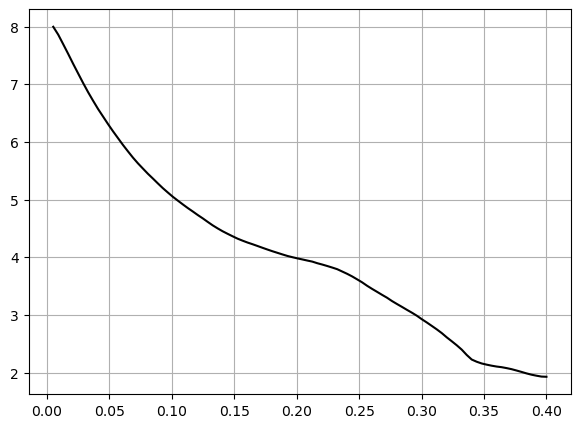

In [13]:
#  Ячейка № 13

# задание функции, возвращающей значения
# автокорреляционной функции скорости для
# для данного значений t2-t1


def CorrV(z, N, Lx, Ly, N_start, dK, Ng):
    i = 0
    j = 0
    V = 0

    while N_start + (i + 1) * dK < z.shape[2] - 1:
        while N_start + (i + 1) * dK + j < z.shape[2] - 1 - dK:
            for m in range(N):
                V = (
                    V
                    + z[m, 2, i + N_start + j] * z[m, 2, N_start + (i + 1) * dK + j]
                    + z[m, 3, i + N_start + j] * z[m, 3, N_start + (i + 1) * dK + j]
                )

                j = j + 1

        i = i + 1

    V = V / (N * j)

    return V


# задание момента времени,
# начиная с которого
# состояние системы
# считается равновесным
T_start = 0.5

# вычисление соответствующего
# номера элемента массива z
N_start = int(T_start / dt)

# задание длин интервалов t2 - t1
Delta_t = np.linspace(0.005, 0.4, 100)


# задание функции, преобразующей
# массив float в целые числа
def f(x):
    return int(x)


f2 = np.vectorize(f)

# вычисление номеров МД-шагов,
# соответствующих числам в массиве Dk
Dk = f2(Delta_t / dt)

#
Ng = f2((T_start + Delta_t) / dt)

Corr = np.zeros(len(Delta_t))

for i in range(len(Delta_t)):
    Corr[i] = CorrV(z, N, Lx, Ly, N_start, Dk[i], Ng[i])

fig = plt.figure(figsize=(7, 5))
plt.plot(Delta_t, Corr, color="black")
plt.grid(True)

plt.show()